In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC as SklearnSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

**SVM Classifier** 

**Goal: Find the hyperplane that separates classes with the**
   
   MAXIMUM MARGIN (widest gap between the two classes).

**Model:**
#### y_hat = sign(X @ w + b)
  **If positive → class 1, if negative → class -1**

***Cost function (Hinge Loss + Regularization):**
    **J = (1/2) * ||w||^2 + C * sum(max(0, 1 - y * (X @ w + b)))**

   **First term: regularization (keep w small for wide margin)**
   **Second term: hinge loss (penalize misclassifications)**

#####  C: trade-off between margin width and classification errors

**Gradients:**
  If y * (X @ w + b) >= 1 (correctly classified, outside margin):
####     dw = w          (only regularization gradient)
####     db = 0
     **Else (misclassified or inside margin):**
          dw = w - C * y * X
          db = -C * y


**Equation of the Hyperplane:**

**y = wx - b** 

**Gradient Descent:**

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

**Learning Rate:**

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.

In [8]:
class SVMScratch:

    def __init__(self, learning_rate= 0.001, lambda_param=0.01, n_iterations=1000):

        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iter = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape

        y_svm = np.where(y <= 0, -1, 1)

        self.weights = np.zeros(n_features)
        self.bias = 0 
        self.cost_history = []

        for epoch in range(self.n_iter):
            total_cost = 0

            for i in range(n_samples):
                condition = y_svm[i] * (X[i] @ self.weights + self.bias) >=1

                if condition:
                    self.weights -= self.lr * (self.lambda_param * self.weights)
                else:
                    self.weights -= self.lr * (self.lambda_param * self.weights - y_svm[i] * X[i])
                    self.bias -= self.lr * (-y_svm[i])

                hinge = max(0, 1 - y_svm[i] * (X[i] @ self.weights + self.bias))
                total_cost += hinge

            reg_cost = 0.5 * self.lambda_param * np.sum(self.weights ** 2)
            total_cost = reg_cost + total_cost / n_samples
            self.cost_history.append(total_cost)

        return self

    def predict(self, X):
        linear_output = X @ self.weights + self.bias
        return np.where(np.sign(linear_output) == -1, 0, 1)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)
        

In [9]:
np.random.seed(42)

X, y = make_classification(
    n_samples = 300, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1,
    class_sep=1.5, random_state=42
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

split = int(0.8 * len(X))

X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y[:split], y[split:]

model = SVMScratch(learning_rate=0.001, lambda_param=0.01, n_iterations=500)
model.fit(X_train, y_train)

print(f"Weights: {np.round(model.weights, 4)}")
print(f"Bias:    {model.bias:.4f}")
print(f"\nTrain accuracy: {model.score(X_train, y_train) * 100:.1f}%")
print(f"Test accuracy:  {model.score(X_test, y_test) * 100:.1f}%")

Weights: [0.2522 2.364 ]
Bias:    0.1630

Train accuracy: 98.3%
Test accuracy:  100.0%


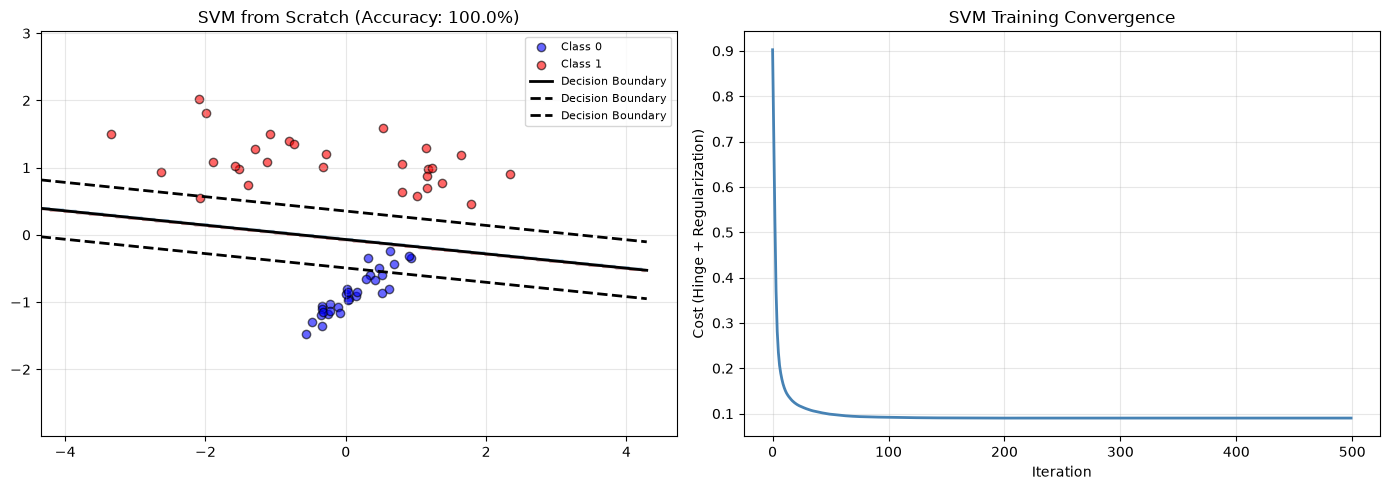

In [12]:
fig,  axes = plt.subplots(1, 2, figsize=(14,5))

x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

axes[0].contour(xx, yy, Z, alpha=0.3, cmap='RdBu')
axes[0].scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1],
                c='blue', label='Class 0', alpha=0.6, edgecolors='k')
axes[0].scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1],
                c='red', label='Class 1', alpha=0.6, edgecolors='k')

w = model.weights
b = model.bias

x_line = np.linspace(x_min, x_max, 100)
decision = -(w[0] * x_line + b) / w[1]
margin_up = -(w[0] * x_line + b - 1)/ w[1]
margin_down = -(w[0] * x_line + b + 1)/ w[1]

axes[0].plot(x_line, decision, 'k-', linewidth=2, label='Decision Boundary')
axes[0].plot(x_line, margin_up, 'k--', linewidth=2, label='Decision Boundary')
axes[0].plot(x_line, margin_down, 'k--', linewidth=2, label='Decision Boundary')
axes[0].set_ylim(y_min, y_max)
axes[0].set_title(f"SVM from Scratch (Accuracy: {model.score(X_test, y_test)*100:.1f}%)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(model.cost_history, color='steelblue', linewidth=2)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost (Hinge + Regularization)')
axes[1].set_title('SVM Training Convergence')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svm_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
## Comparing with Sklearn 

sklearn_svm = SklearnSVM(kernel='linear', C=100)
sklearn_svm.fit(X_train, y_train)

print(f"{'Metric':<20} {'From Scratch':>15} {'Scikit-Learn':>15}")
print(f"{'-'*50}")
print(f"{'Train Accuracy':<20} {model.score(X_train, y_train)*100:>14.1f}% {sklearn_svm.score(X_train, y_train)*100:>14.1f}%")
print(f"{'Test Accuracy':<20} {model.score(X_test, y_test)*100:>14.1f}% {sklearn_svm.score(X_test, y_test)*100:>14.1f}%")
print(f"{'Weights':<20} {np.round(model.weights, 3)} {np.round(sklearn_svm.coef_[0], 3)}")

Metric                  From Scratch    Scikit-Learn
--------------------------------------------------
Train Accuracy                 98.3%           98.3%
Test Accuracy                 100.0%          100.0%
Weights              [0.252 2.364] [0.573 4.618]


In [ ]:
print("""
============================================================
PCA FROM SCRATCH — COMPLETE
============================================================

What was built:
  - PCAScratch class using only NumPy
  - Covariance matrix computation
  - Eigendecomposition for finding principal components
  - Variance explained calculation
  - fit(), transform(), fit_transform(), inverse_transform()

Key concepts:
  - PCA finds directions of maximum variance
  - First PC captures most variance, second captures next most
  - Scree plot helps decide how many components to keep
  - 95% variance threshold is a common rule of thumb
  - PCA is used for visualization, noise reduction, and preprocessing

Verified against scikit-learn: results match.